In [96]:
import torch
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm  # tqdm для отображения прогресса
import time  # Для измерения времени

In [97]:
# Определить преобразование данных
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

batch_size = 4

# Загрузить обучающий набор данных
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

# Загрузить тестовый набор данных
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

# Классы изображений в CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


In [98]:
print('Shape of training dataset:', trainset.data.shape)
print('Shape of testing dataset:', testset.data.shape)

Shape of training dataset: (50000, 32, 32, 3)
Shape of testing dataset: (10000, 32, 32, 3)


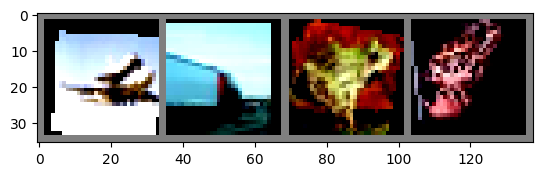

plane truck frog  frog 


In [99]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [100]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # padding добавляет нули по краям изображения
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2) # 16x16
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128) #16x16
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2,2) # 8x8

        self.fc1 = nn.Linear(2048, 256)
        self.dropout = nn.Dropout(0.5) # Dropout для регуляризации
        self.fc2 = nn.Linear(256, 120)
        self.fc3 = nn.Linear(120, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool2(F.relu(self.bn4(self.conv4(x))))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        # print("Размерность тензора перед fc1:", x.shape)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

In [101]:
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

criterion = nn.CrossEntropyLoss()

# Гиперпараметры (можно вынести в отдельный конфиг)
num_epochs = 5          # Увеличьте количество эпох, если модель не сходится
learning_rate = 0.001
weight_decay = 0.0005     # L2 регуляризация
step_size = 7             # Как часто уменьшать learning rate
gamma = 0.1               # На сколько уменьшать learning rate

In [102]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
net.to(device)
criterion = criterion.to(device)

In [103]:
# Оптимизатор Adam с L2 регуляризацией
optimizer = optim.Adam(net.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Уменьшайте скорость обучения каждые step_size эпох в gamma раз
# Планировщик скорости обучения (Learning Rate Scheduler)
scheduler = lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

In [104]:
# Функция для вычисления точности
def calculate_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    total = labels.size(0)
    return correct / total

In [105]:
# Цикл обучения
start_time = time.time()
for epoch in range(num_epochs):
    net.train()  # Переводим модель в режим обучения
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Используем tqdm для отображения прогресса обучения
    loop = tqdm(enumerate(trainloader, 0), total=len(trainloader), desc=f"Epoch {epoch+1}/{num_epochs}")
    for i, data in loop:
        # Получаем данные и переносим их на устройство
        inputs, labels = data[0].to(device), data[1].to(device)

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход (forward pass)
        outputs = net(inputs)
        loss = criterion(outputs, labels)

        # Обратный проход (backward pass) и оптимизация
        loss.backward()
        optimizer.step()

        # Считаем статистику
        running_loss += loss.item()
        accuracy = calculate_accuracy(outputs, labels)
        correct_predictions += accuracy * labels.size(0)
        total_samples += labels.size(0)

        # Обновляем описание tqdm
        loop.set_postfix(loss=running_loss/(i+1), accuracy=correct_predictions/total_samples)

    # Шаг планировщика скорости обучения
    scheduler.step()

    # Выводим статистику после каждой эпохи
    epoch_loss = running_loss / len(trainloader)
    epoch_accuracy = correct_predictions / total_samples
    print(f"Epoch {epoch+1} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}, LR: {scheduler.get_last_lr()}")

    # Оценка на тестовом наборе (или валидационном)
    net.eval()  # Переводим модель в режим оценки
    test_loss = 0.0
    test_correct_predictions = 0
    test_total_samples = 0

    with torch.no_grad():  # Отключаем вычисление градиентов во время оценки
        for data in testloader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            accuracy = calculate_accuracy(outputs, labels)
            test_correct_predictions += accuracy * labels.size(0)
            test_total_samples += labels.size(0)

    test_loss = test_loss / len(testloader)
    test_accuracy = test_correct_predictions / test_total_samples
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


end_time = time.time()
training_time = end_time - start_time
print(f"Training complete in {training_time:.2f} seconds")

print('Finished Training')

Epoch 1/10: 100%|██████████| 12500/12500 [02:15<00:00, 92.20it/s, accuracy=0.278, loss=1.89] 

Epoch 1 - Loss: 1.8880, Accuracy: 0.2778, LR: [0.001]


Test Loss: 1.5149, Test Accuracy: 0.4245


Epoch 2/10: 100%|██████████| 12500/12500 [02:14<00:00, 92.61it/s, accuracy=0.435, loss=1.54] 

Epoch 2 - Loss: 1.5439, Accuracy: 0.4345, LR: [0.001]


...

Epoch 9 - Loss: 0.9154, Accuracy: 0.6821, LR: [0.0001]


Test Loss: 0.7573, Test Accuracy: 0.7412


Epoch 10/10: 100%|██████████| 12500/12500 [02:17<00:00, 91.21it/s, accuracy=0.691, loss=0.884]

Epoch 10 - Loss: 0.8837, Accuracy: 0.6910, LR: [0.0001]


Test Loss: 0.7336, Test Accuracy: 0.7480
Training complete in 1442.25 seconds
Finished Training


In [106]:
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

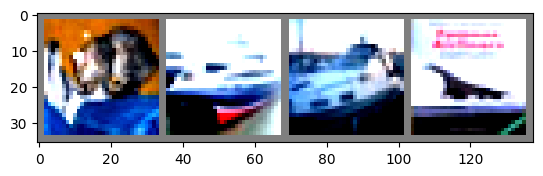

GroundTruth:  cat   ship  ship  plane


In [113]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [114]:
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))
outputs = net(images)

In [115]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  dog   ship  car   plane
